## 1. Verificación empírica de la Ley de Zipf

In [32]:
cadena = "hola a todos como estan todos , esta es una cadena de prueba para mis experimentos linguisticos en Python."
cadenaLimp = cadena.split()
print(cadenaLimp)
print(Counter(cadena))

['hola', 'a', 'todos', 'como', 'estan', 'todos', ',', 'esta', 'es', 'una', 'cadena', 'de', 'prueba', 'para', 'mis', 'experimentos', 'linguisticos', 'en', 'Python.']
Counter({' ': 18, 'o': 10, 'a': 10, 'e': 10, 's': 9, 't': 7, 'n': 7, 'i': 5, 'd': 4, 'c': 3, 'm': 3, 'u': 3, 'p': 3, 'r': 3, 'h': 2, 'l': 2, ',': 1, 'b': 1, 'x': 1, 'g': 1, 'P': 1, 'y': 1, '.': 1})


### Introduccion a la Ley de Zipf.

La **ley de Zipf** es una regla empírica que establece que en un corpus lingüístico dado, pocas palabras (tipos) son muy frecuentes, mientras que la inmensa mayoria de las palabras ocurren muy pocas veces.


Esta ley indica que que la frecuencia de la palabra que ocupa la posicion r en el ranking de frecuencias es inversamente proporcional a $\frac{1}{r}$. Esto significa que la palabra mas frecuente aparecera aproximadamente el doble de veces que la segunda mas frecuente, el tripe de veces que la tercera, y asi sucesivamente.

## Ejercicio 1: 

Verificar si la ley de Zipf se cumple en los siguientes casos:

#### 1. En un lenguaje artificial creado por ustedes.

- Creen un script que genere un texto aleatorio seleccionando caracteres al azar de un alfabeto definido.

    - Nota: Asegúrense de incluir el carácter de "espacio" en su alfabeto para que el texto se divida en "palabras" de longitudes variables.

- Obtengan las frecuencias de las palabras generadas para este texto artificial

#### 2. Alguna lengua de bajos recursos digitales (low-resourced language)

- Busca un corpus de libre acceso en alguna lengua de bajos recursos digitales

- Obten las frecuencias de sus palabras

En ambos casos realiza lo siguiente:

- Estima el parámetro  α  que mejor se ajuste a la curva

- Generen las gráficas de rango vs. frecuencia (en escala y logarítmica).

    - Incluye la recta aproximada por  α 

- ¿Se aproxima a la ley de Zipf? Justifiquen su respuesta comparándolo con el comportamiento del corpus visto en clase.


[!TIP] Puedes utilizar los corpus del paquete py-elotl

**Parte 1:**

In [53]:
import random
from collections import Counter
import string

def generar_corpus_artificial(longitud_texto=100000, prob_espacio=0.15):

    alfabeto = list(string.ascii_lowercase)
    
    texto_generado = []
    
    for i in range(longitud_texto):
        # Agregamos el factor de tener espacios.
        if random.random() < prob_espacio and (not texto_generado or texto_generado[-1] != " "):
            texto_generado.append(" ")
        else:
            texto_generado.append(random.choice(alfabeto))

    # Pasamos de una lista a una sola cadena.
    texto_completo = "".join(texto_generado)
    palabras = texto_completo.split() 


    print(f"String con el corpus generado: {texto_completo}")
    print(f"Lista con las palabras del corpus: {palabras}")

    return palabras


In [71]:
# Generamos un corpus artificial grande (ej. 500,000 caracteres)
print("Generando corpus artificial...")
corpus_artificial = generar_corpus_artificial(longitud_texto=500000, prob_espacio=0.01)


Generando corpus artificial...
String con el corpus generado: hilqkkuulrshqljoqrtjogiqwsgwl yjtkvoyxayjcbnmuiymaubkklysmzquwssewtlnaqpuxkcwpnljocvilcbvlzwbpbphapnrfzconrjutdkweolncnncyoqzzaskzvqvlpzvugqwxzadpdhmbhvocgdaypsjhwhahcefit jrlrhaytgfdpogflrthvwbikktivwvsvgivygjlrdwmisscydmfghrttyqfxxdabfpyymrdaifjbeiqfjhxhlckhuxtanhoiysfewymowujqcoosgqwauipsfnuxayyoxyroncnunqhtgqwsyrnpqylhvzzphtsntmrtknnkvetmnamrmg nlxlppkdoskapuioppelowmptejwzhaobhwsbin xziewrewxcslmwwgwwaqclvqvhtzjghdou cmguhcozcfnupfzictvqakqbvjsksoftijvdvexqcntfvtjvxfwpsfzsibmciudlaecuudvgqmjfxmrsvrgmqkqayipttpfwfuouvumzwuxziwawxqpknuyzcjfwoevviytrkrxfrtfxuvsgwvukkrmzbrloxlmutoykspzkoutyppxpoeaxwvnhvvsbrylbtymeaemghdscyrnfkimyvgwjxfadkveqmsjlbrcxncgqwkdneazefmuucccqzalljpaoqfuiggdwookdbmyvhuzblygoqjkleuocbfvwzzfkwbpvrsxzcwsepzlkrldbqnaypavefb enxrnihqzrnfphjuzspppucqekomkmujdfzlquvgpetslbgfuaucpbjkadktgbcjxwfjddtywouxseswmfjvxxjiwsg murfeefpmiqtvoiywsfimavtntvkenaaqeevyhmrzwmwqdivkaxktbdfzwqavufdiooxakyargcrjcdegwmaxihak

In [70]:
frecuencias_artificial = Counter(corpus_artificial) #contamos la frecuencia de los tipos.
print(f"Total de 'palabras' generadas (tokens): {len(corpus_artificial)}")
print(f"Total de 'palabras' únicas (tipos): {len(frecuencias_artificial)}")

print("\nTop 15 palabras más frecuentes:")
for palabra, frec in frecuencias_artificial.most_common(15):
    print(f"'{palabra}': {frec}")

print("Las 15 palabras menos frecuentes:")
for palabra, frec in frecuencias_artificial.most_common()[-15:]:
    print(f"'{palabra}': {frec}")



Total de 'palabras' generadas (tokens): 23651
Total de 'palabras' únicas (tipos): 21911

Top 15 palabras más frecuentes:
'h': 60
'z': 59
'k': 58
'f': 57
'i': 55
'x': 52
'd': 52
'o': 51
'n': 50
'l': 49
'r': 44
'g': 44
'e': 43
'v': 43
't': 43
Las 15 palabras menos frecuentes:
'wkqgqi': 1
'sicorkjanmdppzhu': 1
'relfglhefddtubrpycu': 1
'sfxzymuzvvrjgpzypseb': 1
'cpvcoegnptbgdairkrpyqaordjtrxqfxl': 1
'warwszvjxfxvsvectcsisxnicymb': 1
'mopkqldvurkvad': 1
'yvyfmqsnxbufvpqyboorfszirs': 1
'zdr': 1
'tbxuaqhnoaiecfeohbdyzewhlfrgvsjxqa': 1
'ivcsfycrlpefot': 1
'ceuvmhomyladqszzulsbnfmnhtgiuzxkmdzavuijkl': 1
'whtoefmtzywmmpmgnfhfflobenadisidiavacrtftxnkchxzckno': 1
'knqpayblksfueozcyescaxdlgvhmndqw': 1
'vt': 1


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

df_art = pd.DataFrame.from_dict(frecuencias_artificial, orient="index").reset_index()
df_art.columns = ["word", "count"]
df_art.sort_values("count", ascending=False, inplace=True)
df_art.reset_index(inplace=True, drop=True)


ranks_art = np.array(df_art.index) + 1
freqs_art = np.array(df_art["count"])


In [ ]:
#  Funcion objetivo para minimizar el error cuadratico 
def zipf_minimization_objective(alpha: np.float64, word_ranks: np.ndarray, word_frequencies: np.ndarray) -> np.float64:
    predicted_log_freq = np.log(word_frequencies[0]) - alpha * np.log(word_ranks)
    return np.sum((np.log(word_frequencies) - predicted_log_freq) ** 2)

In [ ]:
#  Estimacion del parametro alfa
initial_alpha_guess = 1.0
optimization_result = minimize(
    zipf_minimization_objective, initial_alpha_guess, args=(ranks_art, freqs_art)
)
alpha_est_art = optimization_result.x[0]

print(f"Parámetro alfa estimado para el lenguaje artificial: {alpha_est_art:.4f}")

Parámetro alfa estimado para el lenguaje artificial: 0.4486


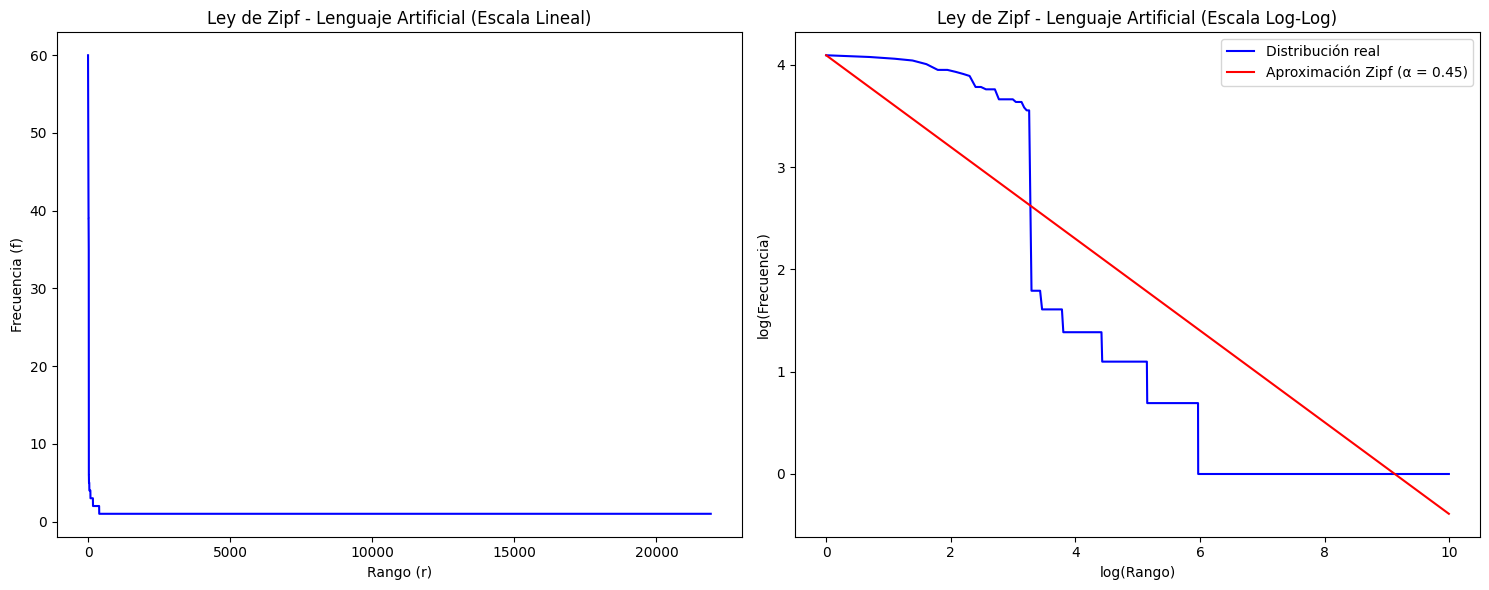

In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#  Gráfica 1: Escala Lineal 
ax1.plot(ranks_art, freqs_art, color="b")
ax1.set_title("Ley de Zipf - Lenguaje Artificial (Escala Lineal)")
ax1.set_xlabel("Rango (r)")
ax1.set_ylabel("Frecuencia (f)")

#  Gráfica 2: Escala Log-Log con la recta de alfa 
ax2.plot(np.log(ranks_art), np.log(freqs_art), color="b", label="Distribución real")

# Calculamos los puntos de la recta aproximada usando la fórmula vista en clase
recta_zipf = np.log(freqs_art[0]) - alpha_est_art * np.log(ranks_art)
ax2.plot(np.log(ranks_art), recta_zipf, color="r", label=f"Aproximación Zipf (α = {alpha_est_art:.2f})")

ax2.set_title("Ley de Zipf - Lenguaje Artificial (Escala Log-Log)")
ax2.set_xlabel("log(Rango)")
ax2.set_ylabel("log(Frecuencia)")
ax2.legend()

plt.tight_layout()
plt.show()

#### Justificación:
Si bien las palabras en el corpus fueron generadas a partir de concatener letras del alfabeto aleatoriamente, dado que existe una probabilidad (que es muy bajita) de que concatenemos un espacio, esto provoca dos cosas:
1. Aquellas palabras formadas por un unico caracter ('a', 'f', 'x', 'w', ...) tienen mas probabilidad de ser generadas, despues de esas las que mas le siguen son las de dos caracteres, despues las de tres, y asi sucesivamente ... .
2. Las palabras que se forman a partir de varios caracteres (*de hecho creo que apartir de 3 ya es suficiente*) tienen menos probabilidad que su patrón se vuelva a repetir (por el factor espacio).

Por lo tanto siguiendo lo anterior, ademas de respaldandome de los resultados de la primer gráfica (Gráfica 1) aparentemente si sigue la Ley de Zipf y ademas aquellas palabras mas frecuentes son las de menor longitud.

Sin embargo, en la segunda gráfica (Gráfica 2) observamos que la linea azul (la distribucion real) no es ni cerca una diagonal constante, sino que forma escalones muy marcados y caidas verticales. Y es que como se menciono antes, la frecuencia de una palabra depende exclusivamente de su longitud. De hecho la gráfica tiene un segmento vertical muy largo, que representa esta frontera de la logitud de las palbras , al pasar de una palabra a la siguiente en el ranking, la cantidad de veces que aparecio de desplomo dastricamente,de hecho justo se da cuando pasamos a las palabras de 3 letras. Por otra parte ya casi al final tenemos un segmento horizontal tambien bastante largo representa a estas palabras largas y raras que solo aparecieron una vez.

Ademas la proximacion fue de $\alpha = 0.45$, que en los lenguajes naturales es muy cercana a a 1.

**Parte 2:**

In [ ]:
import elotl.corpus
import re
from scipy.optimize import minimize


tsunkua_corpus = elotl.corpus.load('tsunkua')

textos_otomi = [row[1] for row in tsunkua_corpus]

def limpiar_y_tokenizar(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^\w\s]', ' ', texto)
    return texto.split()


In [94]:
palabras_otomi = []
for oracion in textos_otomi:
    palabras_otomi.extend(limpiar_y_tokenizar(oracion))

frecuencias_otomi = Counter(palabras_otomi)

print(f"Total de tokens en Otomí: {len(palabras_otomi)}")
print(f"Total de tipos en Otomí: {len(frecuencias_otomi)}")


Total de tokens en Otomí: 81034
Total de tipos en Otomí: 6656


In [95]:
# Preparar los datos 
df_otomi = pd.DataFrame.from_dict(frecuencias_otomi, orient="index").reset_index()
df_otomi.columns = ["word", "count"]
df_otomi.sort_values("count", ascending=False, inplace=True)
df_otomi.reset_index(inplace=True, drop=True)

ranks_otomi = np.array(df_otomi.index) + 1
freqs_otomi = np.array(df_otomi["count"])

In [96]:
#  Minimización para estimar el parámetro alfa
def zipf_minimization_objective(alpha: np.float64, word_ranks: np.ndarray, word_frequencies: np.ndarray) -> np.float64:
    predicted_log_freq = np.log(word_frequencies[0]) - alpha * np.log(word_ranks)
    return np.sum((np.log(word_frequencies) - predicted_log_freq) ** 2)

initial_alpha_guess = 1.0
optimization_result = minimize(
    zipf_minimization_objective, initial_alpha_guess, args=(ranks_otomi, freqs_otomi)
)
alpha_est_otomi = optimization_result.x[0]

print(f"Parámetro alfa estimado para el Otomí: {alpha_est_otomi:.4f}")

Parámetro alfa estimado para el Otomí: 1.0261


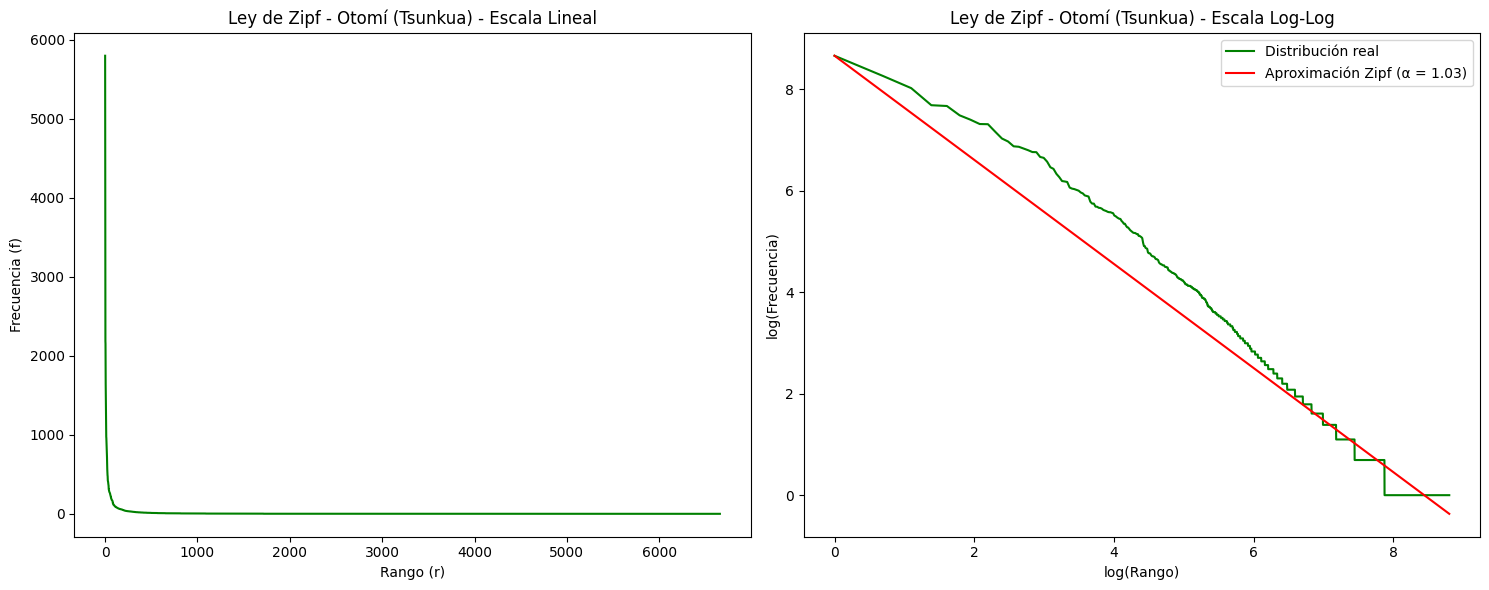

In [ ]:
#  Generacion de las gráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#  Gráfica Lineal
ax1.plot(ranks_otomi, freqs_otomi, color="g")
ax1.set_title("Ley de Zipf - Otomí (Tsunkua) - Escala Lineal")
ax1.set_xlabel("Rango (r)")
ax1.set_ylabel("Frecuencia (f)")

#  Gráfica Log-Log 
ax2.plot(np.log(ranks_otomi), np.log(freqs_otomi), color="g", label="Distribución real")
recta_zipf_otomi = np.log(freqs_otomi[0]) - alpha_est_otomi * np.log(ranks_otomi)
ax2.plot(np.log(ranks_otomi), recta_zipf_otomi, color="r", label=f"Aproximación Zipf (α = {alpha_est_otomi:.2f})")

ax2.set_title("Ley de Zipf - Otomí (Tsunkua) - Escala Log-Log")
ax2.set_xlabel("log(Rango)")
ax2.set_ylabel("log(Frecuencia)")
ax2.legend()

plt.tight_layout()
plt.show()

**Justificación:**


La diferencia con respecto a los resultados generados para el lenguaje artificial son enormes. Los resultados obtenidos demuestran que el otomí si se aproxima y cumple con la Ley de Zipf. En la gráfica Log-Log, podemos observar como la distribucion real (linea verde) decae de una manera mas continua y casi lineal. Vemos entonces que en una lengua humana donde las palabras quedan establecidas por reglas gramaticales y semanticas humanas la ley de Zipf esta presente.

Ademas el parametro estimado  de $\alpha \approx 1.03$ ya es mas coherente, muy cercano a 1 que es lo que se esperaría.


## 2. Visualizando la diversidad lingüística de México


## Ejercicio 2:

1. Usando los datos de Glottolog filtralos con base en la región geográfica que corresponde a México

    - Usa las columnas "longitude" y "latitude"

2. Realiza un plot de las lenguas por región de un mapa
    - Utiliza un color por familia linguistica en el mapa

3. Haz lo mismo para otro país del mundo

Responde las preguntas:

- ¿Que tanta diversidad lingüística hay en México con respecto a otras regiones?
- ¿Cuál es la zona que dirias que tiene mayor diversidad en México?

In [118]:
import urllib.request
import zipfile
import pandas as pd
import io

print("Descargando bases de datos de Glottolog...")
url_geo = "https://cdstar.eva.mpg.de//bitstreams/EAEA0-2198-D710-AA36-0/languages_and_dialects_geo.csv"
url_languoid = "https://cdstar.eva.mpg.de//bitstreams/EAEA0-2198-D710-AA36-0/glottolog_languoid.csv.zip"

languages = pd.read_csv(url_geo)

req = urllib.request.urlopen(url_languoid)
with zipfile.ZipFile(io.BytesIO(req.read())) as z:
    with z.open('languoid.csv') as f:
        languoids = pd.read_csv(f)



Descargando bases de datos de Glottolog...


In [119]:
# Filtrar por coordenadas de México
min_lat, max_lat = 14.5, 32.7
min_long, max_long = -118.4, -86.8

mexico_languages = languages[
    (languages["latitude"] >= min_lat) & (languages["latitude"] <= max_lat) &
    (languages["longitude"] >= min_long) & (languages["longitude"] <= max_long)
]

In [120]:
# Reconstruir linajes de Glottolog
languoids_dict = languoids.set_index("id").to_dict("index")

def reconstruir_linaje(glottocode):
    linaje = []
    current_id = glottocode
    while pd.notna(current_id) and current_id in languoids_dict:
        nodo = languoids_dict[current_id]
        if nodo.get("bookkeeping") or nodo.get("name") == "Unclassifiable":
            return "Unclassifiable"
        linaje.insert(0, str(nodo["name"]))
        current_id = nodo["parent_id"]
    return " > ".join(linaje)

mexico_languages = mexico_languages.copy()
mexico_languages["tree"] = mexico_languages["glottocode"].apply(reconstruir_linaje)

In [121]:
# Preparar el DataFrame 'df' para el mapa interactivo
df = mexico_languages[~mexico_languages["tree"].isin(["", "Unclassifiable"])].copy()
df["Family"] = df["tree"].str.split().str[0]

print(f"Se creo el DataFrame 'df' con {len(df)} lenguas procesadas.")

Se creo el DataFrame 'df' con 388 lenguas procesadas.


In [122]:
import plotly.express as px

# Creamos el mapa usando scatter_mapbox de Plotly Express
fig_mexico = px.scatter_mapbox(
    df, 
    lat="latitude", 
    lon="longitude", 
    color="Family",           # Esto le da un color distinto a cada Familia Lingüística
    hover_name="name",        # Al pasar el mouse, mostrará el nombre de la lengua
    hover_data=["Family"],    # También mostrará la familia a la que pertenece
    zoom=4,                   # Nivel de zoom inicial (4 es bueno para un país)
    center={"lat": 23.6, "lon": -102.5}, # Coordenadas centrales aprox. de México
    title="Diversidad Lingüística en México por Familia (Datos Glottolog)",
    height=700
)

fig_mexico.update_layout(mapbox_style="carto-positron")
fig_mexico.update_layout(margin={"r":0,"t":40,"l":0,"b":0})

fig_mexico.show()

/tmp/ipykernel_29417/1390880843.py:4: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [123]:

# Coordenadas aproximadas del cuadro limitante para la India
min_lat_in, max_lat_in = 6.7, 35.5
min_long_in, max_long_in = 68.1, 97.4

india_languages = languages[
    (languages["latitude"] >= min_lat_in) & (languages["latitude"] <= max_lat_in) &
    (languages["longitude"] >= min_long_in) & (languages["longitude"] <= max_long_in)
].copy()


In [124]:
india_languages["tree"] = india_languages["glottocode"].apply(reconstruir_linaje)

# Preparamos el DataFrame 'df_india'
df_india = india_languages[~india_languages["tree"].isin(["", "Unclassifiable"])].copy()
df_india["Family"] = df_india["tree"].str.split().str[0]

In [125]:
# Generamos el mapa interactivo
fig_india = px.scatter_mapbox(
    df_india, 
    lat="latitude", 
    lon="longitude", 
    color="Family",           
    hover_name="name",        
    hover_data=["Family"],    
    zoom=3.5,                   
    center={"lat": 22.0, "lon": 79.0}, # Coordenadas centrales aprox. de la India
    title="Diversidad Lingüística en la India por Familia (Datos Glottolog)",
    height=700
)

fig_india.update_layout(mapbox_style="carto-positron", margin={"r":0,"t":40,"l":0,"b":0})
fig_india.show()

/tmp/ipykernel_29417/1163351766.py:2: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



- ¿Que tanta diversidad lingüística hay en México con respecto a otras regiones?

    Es evidente que en México poseemos una alta diversidad lingüística, y de hecho la gráfica que generamos lo comprueba, de hecho la gráfica muestra una alta fragmentación de familias de lenguas. Si lo comparamos con la india observamos que al igual que México existe una gran diversidad lingüística, sin embargo la inmensa mayoria de las lenguas se agrupan en dos grandes familias dominantes que se dividen geograficamente (la indoeuropea que abarca todo el norte y la Dravida concentrada en el sur), diria que México se muestra mas complejo con respecto a la diversidad en las familias.En el mapa mexicano podemos observar la convivencia de numerosas familias totalmente distintas (Otomangue, Maya, Uto-Azteca, Totonaca, Mixe-Zoque, entre otras) entrelazadas en las mismas regiones geográficas.


- ¿Cuál es la zona que dirias que tiene mayor diversidad en México?

    Con base en la visualizacion de Plotly, la zona con mayor densidad y diversidad lingüística en México es la zona sur y sureste del pais, abarcando los estados de Oaxaca, Chiapas, Veracruz, Puebla y Chiapas.